In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import make_scorer

print("Imports done.")

Imports done.


In [3]:
df = pd.read_csv("cmi_module1_clean-1.csv")

X = df.drop(columns=["sii"])

# Group classes: 0=None, 1=Mild, 2=High Risk (Moderate+Severe)
y = df["sii"].astype(int).replace({2: 2, 3: 2})

print("Shape:", df.shape)
print("\nNew class distribution:")
print(y.value_counts().sort_index())
print("\nNew class distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(1))

Shape: (8417, 32)

New class distribution:
sii
0    5806
1    1578
2    1033
Name: count, dtype: int64

New class distribution (%):
sii
0    69.0
1    18.7
2    12.3
Name: proportion, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index())

Train shape: (6733, 31)
Test shape: (1684, 31)

Train class distribution:
sii
0    4645
1    1262
2     826
Name: count, dtype: int64

Test class distribution:
sii
0    1161
1     316
2     207
Name: count, dtype: int64


gridsearch

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator': [
        DecisionTreeClassifier(max_depth=1),
        DecisionTreeClassifier(max_depth=2),
        DecisionTreeClassifier(max_depth=3)
    ]
}

ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced'),
    random_state=42,
    algorithm='SAMME'
)
grid_ada = GridSearchCV(ada, param_grid, cv=skf,
                        scoring='f1_macro', n_jobs=-1, verbose=1)
grid_ada.fit(X_train, y_train)

print("Best params:", grid_ada.best_params_)
print("Best CV F1 Macro:", round(grid_ada.best_score_, 4))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'estimator': DecisionTreeClassifier(max_depth=3), 'learning_rate': 1.0, 'n_estimators': 200}
Best CV F1 Macro: 0.4095


evaluate on test set

In [6]:
best_ada_3class = grid_ada.best_estimator_
y_pred_ada_3class = best_ada_3class.predict(X_test)

print("AdaBoost 3-Class Classification Report:")
print(classification_report(y_test, y_pred_ada_3class,
      target_names=["None", "Mild", "High Risk"],
      zero_division=0))

print(f"Accuracy:  {accuracy_score(y_test, y_pred_ada_3class):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ada_3class, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_ada_3class, average='macro', zero_division=0):.4f}")
print(f"F1 Macro:  {f1_score(y_test, y_pred_ada_3class, average='macro', zero_division=0):.4f}")

AdaBoost 3-Class Classification Report:
              precision    recall  f1-score   support

        None       0.74      0.93      0.82      1161
        Mild       0.35      0.12      0.18       316
   High Risk       0.32      0.17      0.23       207

    accuracy                           0.68      1684
   macro avg       0.47      0.41      0.41      1684
weighted avg       0.61      0.68      0.63      1684

Accuracy:  0.6841
Precision: 0.4706
Recall:    0.4068
F1 Macro:  0.4077


confusion matrix

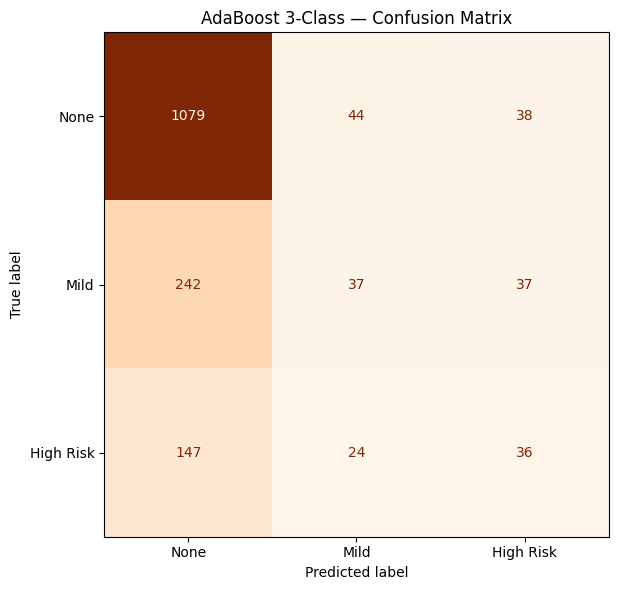

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred_ada_3class)
ConfusionMatrixDisplay(cm, display_labels=["None", "Mild", "High Risk"]).plot(
    ax=ax, colorbar=False, cmap='Oranges'
)
ax.set_title("AdaBoost 3-Class — Confusion Matrix")
plt.tight_layout()
plt.show()

roc curve

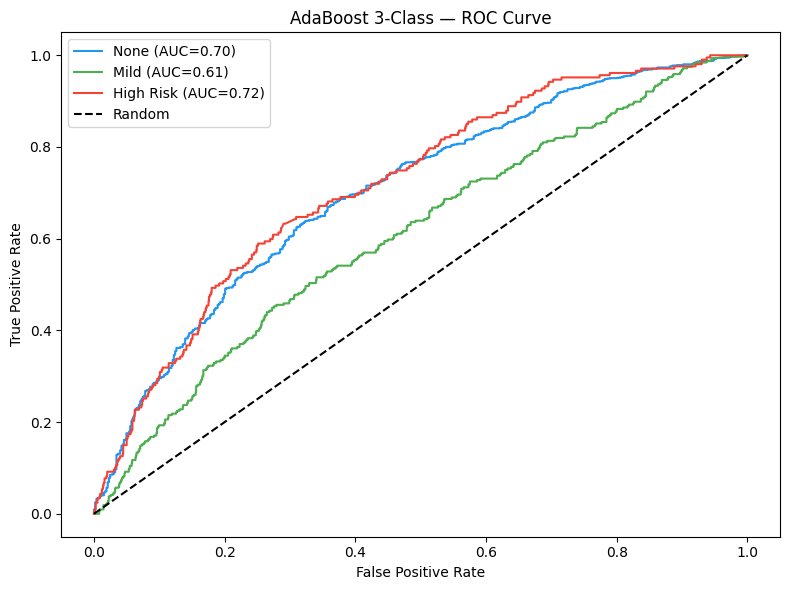

In [8]:
y_prob_ada_3class = best_ada_3class.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

colors = ['#2196F3', '#4CAF50', '#F44336']
class_names = ['None', 'Mild', 'High Risk']

plt.figure(figsize=(8, 6))
for i, (color, name) in enumerate(zip(colors, class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_ada_3class[:, i])
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc(fpr, tpr):.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AdaBoost 3-Class — ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
cv_results_ada_3 = cross_validate(
    best_ada_3class, X_train, y_train,
    cv=skf, scoring={
        'accuracy': 'accuracy',
        'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
        'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0),
        'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
        'recall_macro': make_scorer(recall_score, average='macro', zero_division=0)
    }, n_jobs=-1
)

summary_3 = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Macro)', 'Recall (Macro)',
               'F1 Macro', 'F1 Weighted'],
    'CV Score': [
        cv_results_ada_3['test_accuracy'].mean(),
        cv_results_ada_3['test_precision_macro'].mean(),
        cv_results_ada_3['test_recall_macro'].mean(),
        cv_results_ada_3['test_f1_macro'].mean(),
        cv_results_ada_3['test_f1_weighted'].mean()
    ],
    'CV Std': [
        cv_results_ada_3['test_accuracy'].std(),
        cv_results_ada_3['test_precision_macro'].std(),
        cv_results_ada_3['test_recall_macro'].std(),
        cv_results_ada_3['test_f1_macro'].std(),
        cv_results_ada_3['test_f1_weighted'].std()
    ],
    'Test Score': [
        accuracy_score(y_test, y_pred_ada_3class),
        precision_score(y_test, y_pred_ada_3class, average='macro', zero_division=0),
        recall_score(y_test, y_pred_ada_3class, average='macro', zero_division=0),
        f1_score(y_test, y_pred_ada_3class, average='macro', zero_division=0),
        f1_score(y_test, y_pred_ada_3class, average='weighted', zero_division=0)
    ]
}).round(4)

print("AdaBoost 3-Class — Final Summary Table")
print(summary_3.to_string(index=False))

AdaBoost 3-Class — Final Summary Table
           Metric  CV Score  CV Std  Test Score
         Accuracy    0.6819  0.0080      0.6841
Precision (Macro)    0.4748  0.0209      0.4706
   Recall (Macro)    0.4057  0.0097      0.4068
         F1 Macro    0.4095  0.0126      0.4077
      F1 Weighted    0.6267  0.0068      0.6267


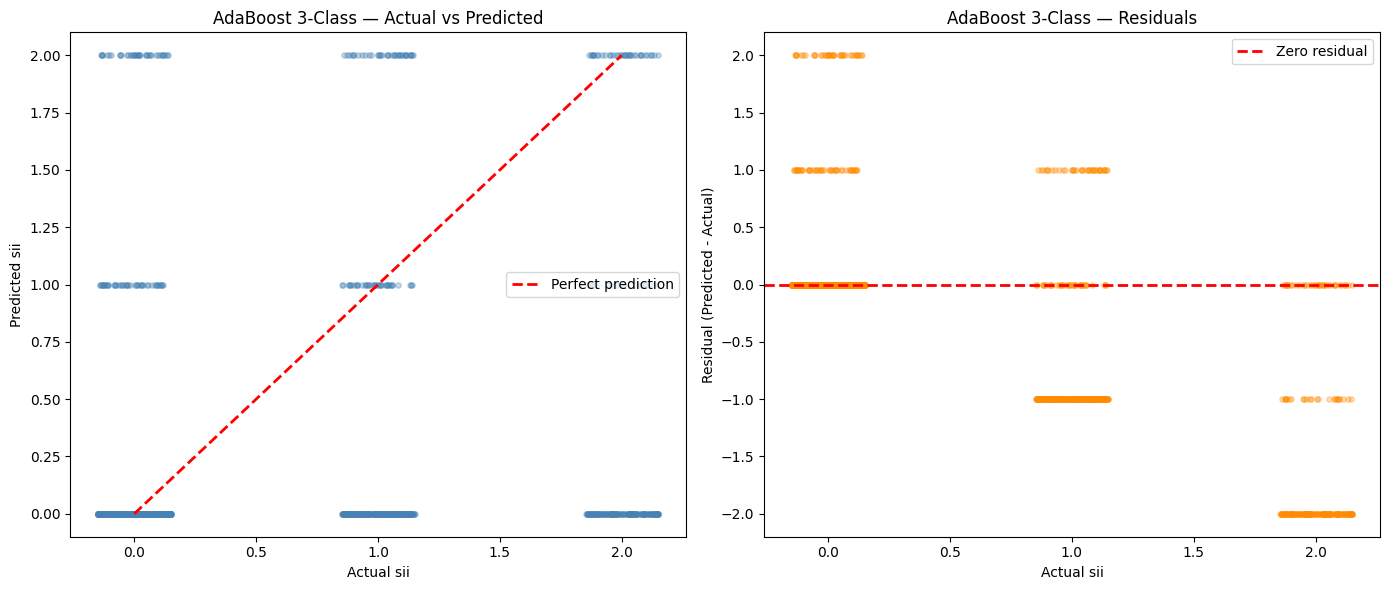

In [10]:
# Residual plot — Actual vs Predicted with jitter for visibility
np.random.seed(42)
jitter = np.random.uniform(-0.15, 0.15, len(y_test))

residuals = y_pred_ada_3class - y_test.values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot — Actual vs Predicted
axes[0].scatter(y_test.values + jitter, y_pred_ada_3class,
                alpha=0.3, color='steelblue', s=15)
axes[0].plot([0, 2], [0, 2], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel("Actual sii")
axes[0].set_ylabel("Predicted sii")
axes[0].set_title("AdaBoost 3-Class — Actual vs Predicted")
axes[0].legend()

# Right plot — Residuals
axes[1].scatter(y_test.values + jitter, residuals,
                alpha=0.3, color='darkorange', s=15)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero residual')
axes[1].set_xlabel("Actual sii")
axes[1].set_ylabel("Residual (Predicted - Actual)")
axes[1].set_title("AdaBoost 3-Class — Residuals")
axes[1].legend()

plt.tight_layout()
plt.show()